In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
import pickle

from arch import arch_model
from tqdm import tqdm #progress bar
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
from hurst import compute_Hc

Loading Data

In [ ]:
forecast_df = pd.read_pickle('garch_vol_forecast.pkl')
log_returns = pd.read_pickle('log_returns_df.pkl')
expected_return = pd.read_pickle('expected_returns_df.pkl')['expected returns']
with open('tickers.pkl','rb') as f:
    tickers = pickle.load(f)

In [ ]:
forecast_df = forecast_df.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
forecast_df

,RELIANCE.NS,TCS.NS,INFY.NS,HDFCBANK.NS,ICICIBANK.NS,HINDUNILVR.NS,ITC.NS,KOTAKBANK.NS,LT.NS,SBIN.NS,...,GRASIM.NS,BPCL.NS,IOC.NS,HEROMOTOCO.NS,BAJAJ-AUTO.NS,SHREECEM.NS,DRREDDY.NS,M&M.NS,INDUSINDBK.NS,APOLLOHOSP.NS
2022-07-13,0.609416,0.249509,0.223965,0.470154,0.343714,0.718547,0.367023,0.765399,0.571933,0.141343,...,1.000000,0.942417,0.406812,0.216802,0.486077,0.222185,0.363656,0.227875,0.242273,0.181655
2022-07-14,0.604415,0.277015,0.195052,0.609353,0.356156,0.709971,0.353776,0.783846,0.529258,0.123696,...,0.991896,0.935531,0.399608,0.175829,0.494706,0.204058,0.350961,0.190123,0.324582,0.356849
2022-07-15,0.585598,0.224121,0.186548,0.479252,0.345578,0.697863,0.389719,0.809499,0.508382,0.177494,...,0.982805,0.922285,0.391856,0.221977,0.514113,0.198280,0.347868,0.188940,0.280783,0.176816
2022-07-18,0.586264,0.223010,0.173013,0.444770,0.339238,0.722030,0.386741,0.757741,0.561077,0.160119,...,0.977703,0.927732,0.383051,0.194307,0.484401,0.194163,0.344643,0.193897,0.253965,0.154272
2022-07-19,0.572567,0.234338,0.276729,0.436498,0.350573,0.709633,0.339019,1.000000,0.575268,0.197032,...,0.971273,0.915643,0.381366,0.179144,0.507671,0.211066,0.348494,0.191978,0.337483,0.087314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-23,0.051332,0.107143,0.061132,0.552764,0.196115,0.091584,0.146834,0.350467,0.150807,0.159483,...,0.210523,0.567761,0.462710,0.150888,0.478720,0.087346,0.184705,0.124919,0.049914,0.191735
2024-01-24,0.245830,0.106603,0.071259,0.915110,0.285471,0.220013,0.188645,0.329666,0.281308,0.177419,...,0.214865,0.670231,0.628635,0.149780,0.501698,0.100985,0.183023,0.134479,1.000000,0.187506
2024-01-25,0.220924,0.107614,0.165000,0.821308,0.406886,0.403950,0.181806,0.350792,0.208986,0.206127,...,0.208433,0.664730,0.622267,0.149190,0.463400,0.098755,0.209807,0.136075,0.508184,0.184952
2024-01-29,0.149855,0.190292,0.035381,0.639270,0.314541,0.438104,0.210730,0.330088,0.199695,0.197916,...,0.188855,0.636463,0.635179,0.147307,0.515311,0.098476,0.209477,0.134145,0.180586,0.190728


In [ ]:
risk_aversion = 0.7
start = '2024-02-01'
end = '2025-06-30'

Selecting Best Two Stocks

In [ ]:
avg_volatility= forecast_df.mean(axis=0)
scores = (1 - risk_aversion) * expected_return - risk_aversion * avg_volatility
display(scores.sort_values(ascending=False).head(5))
selected_stocks = scores.sort_values(ascending=False).head(2).index.tolist()
print("Top 2 selected stocks:", selected_stocks)

TCS.NS          -0.078900
HEROMOTOCO.NS   -0.081997
POWERGRID.NS    -0.085469
INFY.NS         -0.088960
BRITANNIA.NS    -0.090715
dtype: float64

Top 2 selected stocks: ['TCS.NS', 'HEROMOTOCO.NS']


In [ ]:
stock_1=selected_stocks[0]
stock_2=selected_stocks[1]

In [ ]:
stock_1_df= yf.download(stock_1,start=start,end=end,interval="1d")
stock_1_df = stock_1_df.rename(columns={ticker: f'{ticker}' for ticker in tickers})
stock_1_df = stock_1_df.dropna()
stock_1_df = stock_1_df.droplevel(1, axis=1)
stock_1_df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-02-01,3752.922363,3802.339437,3705.112096,3719.669393,2363107
2024-02-02,3862.127197,3879.751667,3770.303891,3773.273832,2826510
2024-02-05,3868.943115,3916.363984,3858.037326,3878.388302,1691523
2024-02-06,4027.369385,4040.904211,3885.204024,3892.020172,4474396
2024-02-07,3976.151367,4045.870923,3966.949614,4043.923452,2124267
...,...,...,...,...,...
2025-06-23,3382.122314,3413.416017,3358.602037,3403.449838,3123421
2025-06-24,3378.932861,3430.458196,3370.561369,3422.983562,3403048
2025-06-25,3433.148926,3438.331289,3388.500401,3395.775760,1757699


In [ ]:
stock_2_df= yf.download(stock_2,start=start,end=end,interval="1d")
stock_2_df = stock_2_df.rename(columns={ticker: f'{ticker}' for ticker in tickers})
stock_2_df = stock_2_df.dropna()
stock_2_df = stock_2_df.droplevel(1, axis=1)
stock_2_df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-02-01,4305.287109,4428.390421,4294.304770,4338.139714,660378
2024-02-02,4427.874023,4476.683609,4308.431335,4315.893753,994506
2024-02-05,4455.423828,4481.424505,4411.636085,4430.409005,425966
2024-02-06,4489.965332,4497.990570,4442.610469,4455.328936,261001
2024-02-07,4499.257324,4521.690864,4439.934734,4496.112770,265821
...,...,...,...,...,...
2025-06-23,4189.747559,4260.281129,4181.768117,4255.650946,580717
2025-06-24,4228.560547,4265.501961,4198.514863,4219.300662,469217
2025-06-25,4236.736816,4292.986374,4226.097881,4237.426582,412213


In [ ]:
realized_vol_1 = log_returns[stock_1].rolling(window=90).std().dropna() * np.sqrt(252)
realized_vol_2 = log_returns[stock_2].rolling(window=90).std().dropna() * np.sqrt(252)

print("Realized Volatility for", stock_1)
print(realized_vol_1.head())

print("\nRealized Volatility for", stock_2)
print(realized_vol_2.head())

Realized Volatility for TCS.NS
Date
2022-07-12    0.258770
2022-07-13    0.259753
2022-07-14    0.260101
2022-07-15    0.259597
2022-07-18    0.256474
Name: TCS.NS, dtype: float64

Realized Volatility for HEROMOTOCO.NS
Date
2022-07-12    0.336509
2022-07-13    0.337101
2022-07-14    0.329464
2022-07-15    0.317475
2022-07-18    0.315527
Name: HEROMOTOCO.NS, dtype: float64


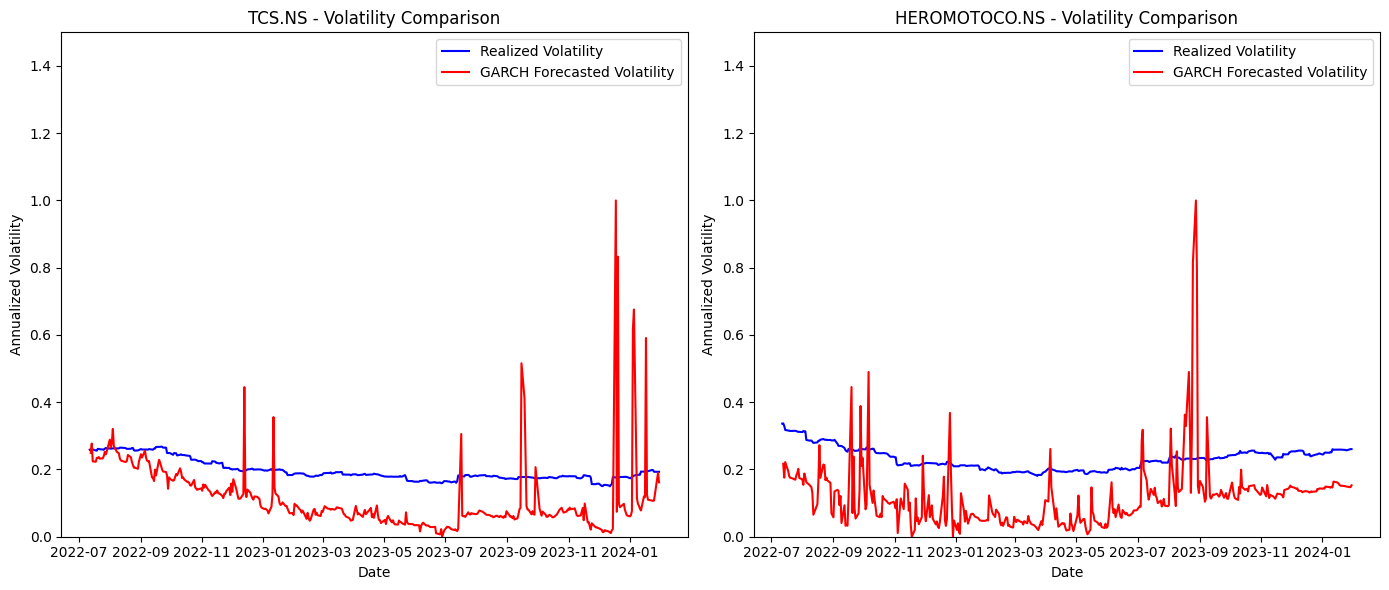

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(realized_vol_1, label='Realized Volatility', color='blue')
plt.plot(forecast_df[stock_1], label='GARCH Forecasted Volatility', color='red')
plt.title(f'{stock_1} - Volatility Comparison')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.ylim(0,1.5)

plt.subplot(1, 2, 2)
plt.plot(realized_vol_2, label='Realized Volatility', color='blue')
plt.plot(forecast_df[stock_2], label='GARCH Forecasted Volatility', color='red')
plt.title(f'{stock_2} - Volatility Comparison')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.ylim(0,1.5)

plt.tight_layout()
plt.show()

In [ ]:
def hurst_exponent(ts):
    H, _, _i = compute_Hc(ts, kind='price', simplified=True)
    return H

def detect_regimes(price: pd.Series,window=100):
    hurst = price.rolling(window).apply(hurst_exponent, raw=False)
    regime = np.select([hurst > 0.5, hurst <= 0.5], [1, -1], -1)
    return pd.Series(regime, index=price.index)

def mean_reverting(df, price_col='Close', window=14, std_mult=2, rsi_buy=30, rsi_sell=70, weight_bb=0.1, weight_rsi=0.9, threshold=0.03):
    prices = df[price_col].values
    prices_series = pd.Series(prices)
    rolling_mean = prices_series.rolling(window).mean().values
    rolling_std = prices_series.rolling(window).std().values
    upper_band = rolling_mean + std_mult * rolling_std
    lower_band = rolling_mean - std_mult * rolling_std
    bb_signals = np.zeros(len(prices))
    bb_signals[prices < lower_band] = 1
    bb_signals[prices > upper_band] = -1
    deltas = prices_series.diff()
    gain = deltas.clip(lower=0)
    loss = -deltas.clip(upper=0)
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    rsi[:window] = 50
    rsi_signals = np.zeros(len(prices))
    rsi_signals[rsi < rsi_buy] = 1
    rsi_signals[rsi > rsi_sell] = -1
    combined_score = weight_bb * bb_signals + weight_rsi * rsi_signals
    final_signals = np.where(combined_score >= threshold, 1,
                    np.where(combined_score <= -threshold, -1, 0))
    return pd.Series(final_signals, index=df.index)

def trend_following(df, price_col='Close', window_adx=14,
                    window_macd_fast=12, window_macd_slow=26, window_macd_signal=9,
                    adx_threshold=20, weight_adx=0.05, weight_macd=0.95, threshold=0.03):

    high = df['High']
    low = df['Low']
    close = df[price_col]
    prev_close = close.shift(1)

    # True range
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)

    # Directional movement
    up_move = high.diff()
    down_move = -low.diff()

    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    atr = tr.rolling(window_adx).mean()

    plus_di = 100 * pd.Series(plus_dm, index=df.index).rolling(window_adx).mean() / atr
    minus_di = 100 * pd.Series(minus_dm, index=df.index).rolling(window_adx).mean() / atr

    # Avoid division by zero
    di_sum = plus_di + minus_di
    dx = (abs(plus_di - minus_di) / di_sum.replace(0, np.nan)) * 100

    adx = dx.rolling(window_adx).mean()

    # MACD
    ema_fast = close.ewm(span=window_macd_fast, adjust=False).mean()
    ema_slow = close.ewm(span=window_macd_slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=window_macd_signal, adjust=False).mean()
    macd_hist = macd_line - signal_line

    macd_signal = np.where(macd_hist > 0, 1, np.where(macd_hist < 0, -1, 0))

    # ADX signal
    adx_signal = np.where(
        (adx >= adx_threshold) & (plus_di > minus_di), 1,
        np.where(
            (adx >= adx_threshold) & (plus_di < minus_di), -1,
            0
        )
    )

    combined_score = weight_adx * adx_signal + weight_macd * macd_signal

    final_signals = np.where(combined_score >= threshold, 1,
                     np.where(combined_score <= -threshold, -1, 0))

    return pd.Series(final_signals, index=df.index)

def strategy(df, price_col='Close', regime_window=100):
    df['regime'] = detect_regimes(df[price_col], window=regime_window)
    df['trend_signal'] = trend_following(df, price_col=price_col)
    df['mean_revert_signal'] = mean_reverting(df, price_col=price_col)

    df['signal'] = np.where(df['regime'] == 1,
                                  df['trend_signal'],
                                  np.where(df['regime'] == -1,
                                           df['mean_revert_signal'],
                                           0))
    return df
def clean_signal(signal):
    last = 0
    cleaned = []

    for sig in signal:
        if sig == 0:
            cleaned.append(0)
        elif sig == last:
            cleaned.append(0)
        else:
            cleaned.append(sig)
            last = sig
    for i, x in enumerate(cleaned):
        if x != 0:
            if x == -1:
                cleaned[i] = 0
            break
    count_1 = sum(1 for x in cleaned if x == 1)
    count_neg1 = sum(1 for x in cleaned if x == -1)

    diff = count_1 - count_neg1
    if diff > 0:
        for i in reversed(range(len(cleaned))):
            if cleaned[i] == 1:
                cleaned[i] = 0
                diff -= 1
                if diff == 0:
                    break
    elif diff < 0:
        for i in reversed(range(len(cleaned))):
            if cleaned[i] == -1:
                cleaned[i] = 0
                diff += 1
                if diff == 0:
                    break

    return np.array(cleaned)

In [ ]:
stock_1_df = strategy(stock_1_df)
#stock_1_df['signal']=clean_signal(stock_1_df['signal'])
stock_1_df['signal'].value_counts()

signal
 0    120
 1    120
-1    107
Name: count, dtype: int64

In [ ]:
stock_2_df = strategy(stock_2_df)
#stock_2_df['signal']=clean_signal(stock_2_df['signal'])
stock_2_df['signal'].value_counts()

signal
-1    148
 1    131
 0     68
Name: count, dtype: int64

In [ ]:
capital = 100000

In [ ]:
def backtesting(df, signal, initial_capital, trailing_stop_pct=0.04):
    trade_idx = []
    opening_trade_idx = []
    closing_trade_idx = []
    entry_date = []
    exit_date = []
    pos = []
    type_of_trade = []

    prev_pos = 0
    shares = 0
    capital = initial_capital

    # Variables for trailing stop
    trail_high = None  # for long trades
    trail_low = None   # for short trades

    portfolio = []
    no_of_shares = []

    for i in range(len(df)):
        price = df.iloc[i]["Close"]
        current_signal = df.iloc[i][signal]

        # Track trailing stop during open positions
        if prev_pos == 1:  # Long trade
            trail_high = max(trail_high, price)
            if price <= trail_high * (1 - trailing_stop_pct):
                current_signal = -1  # trigger close
        elif prev_pos == -1:  # Short trade
            trail_low = min(trail_low, price)
            if price >= trail_low * (1 + trailing_stop_pct):
                current_signal = 1  # trigger close

        # Signal handling
        if current_signal in (1, -1):
            trade_idx.append(i)

        if current_signal == 1:
            if prev_pos == 0:  # Open long
                pos.append(1)
                opening_trade_idx.append(i)
                type_of_trade.append("long")
                entry_date.append(df.index[i])
                shares = int(capital / price)
                capital -= shares * price
                trail_high = price  # reset trailing high
            elif prev_pos == 1:  # Stay long
                pos.append(1)
            elif prev_pos == -1:  # Close short
                pos.append(0)
                closing_trade_idx.append(i)
                exit_date.append(df.index[i])
                capital -= abs(shares) * price
                shares = 0
                trail_low = None

        elif current_signal == -1:
            if prev_pos == 0:  # Open short
                pos.append(-1)
                opening_trade_idx.append(i)
                type_of_trade.append("short")
                entry_date.append(df.index[i])
                shares = -int(capital / price)
                capital += abs(shares) * price
                trail_low = price  # reset trailing low
            elif prev_pos == 1:  # Close long
                pos.append(0)
                closing_trade_idx.append(i)
                exit_date.append(df.index[i])
                capital += shares * price
                shares = 0
                trail_high = None
            elif prev_pos == -1:  # Stay short
                pos.append(-1)
        else:
            pos.append(prev_pos)

        prev_pos = pos[-1]  # update position

        # Portfolio value
        portfolio_value = shares * price + capital
        portfolio.append(portfolio_value)
        no_of_shares.append(shares)

    # Square off last open position
    if pos[-1] != 0:
        pos[-1] = 0
        closing_trade_idx.append(len(df) - 1)
        exit_date.append(df.index[-1])
        price = df.iloc[-1]["Close"]
        if shares > 0:
            capital += shares * price
        elif shares < 0:
            capital -= abs(shares) * price
        shares = 0

    # Compute returns
    returns = []
    for i in range(len(opening_trade_idx)):
        entry = df.iloc[opening_trade_idx[i]]["Close"]
        exit_ = df.iloc[closing_trade_idx[i]]["Close"]
        if type_of_trade[i] == "long":
            returns.append((exit_ - entry) * 100 / entry)
        else:  # short
            returns.append((entry - exit_) * 100 / entry)

    trade_wise_df = pd.DataFrame({
        "Entry Index": opening_trade_idx,
        "Exit Index": closing_trade_idx,
        "Entry Date": entry_date,
        "Exit Date": exit_date,
        "Type of Trade": type_of_trade,
        "No of stock traded": [no_of_shares[i] - (no_of_shares[i - 1] if i > 0 else 0) for i in opening_trade_idx],
        "Return for trade in %": returns,
        "Trade Duration": np.array(closing_trade_idx) - np.array(opening_trade_idx)
    })

    daily_df = pd.DataFrame({
        "Portfolio Value": portfolio,
        "No. of Stock": no_of_shares
    }, index=df.index)

    daily_df["Profit from initial Capital"] = (daily_df["Portfolio Value"] - initial_capital) * 100 / initial_capital
    daily_df["Daily Returns in %"] = daily_df["Portfolio Value"].pct_change() * 100

    return trade_wise_df, daily_df

# Usae
trade_wise_stock_1, daily_stock_1 = backtesting(stock_1_df, "signal", capital / 2)
trade_wise_stock_2, daily_stock_2 = backtesting(stock_2_df, "signal", capital / 2)

In [ ]:
def plot_buy_sell(df, trade_wise_df):
    import plotly.graph_objects as go

    fig = go.Figure()

    # Line plot for stock price
    fig.add_trace(go.Scatter(
        x=df.index,
        y=df["Close"],
        mode='lines',
        name='Close Price',
        line=dict(color='blue')
    ))

    long_trades = trade_wise_df[trade_wise_df["Type of Trade"] == "long"]
    short_trades = trade_wise_df[trade_wise_df["Type of Trade"] == "short"]

    # Long Entry: green triangle-up
    fig.add_trace(go.Scatter(
        x=df.index[long_trades["Entry Index"]],
        y=df["Close"].iloc[long_trades["Entry Index"]],
        mode='markers',
        marker=dict(symbol='triangle-up', color='green', size=12),
        name='Long Entry'
    ))

    # Short Entry: red triangle-down
    fig.add_trace(go.Scatter(
        x=df.index[short_trades["Entry Index"]],
        y=df["Close"].iloc[short_trades["Entry Index"]],
        mode='markers',
        marker=dict(symbol='triangle-down', color='red', size=12),
        name='Short Entry'
    ))

    # Long Exit: red triangle-down
    fig.add_trace(go.Scatter(
        x=df.index[long_trades["Exit Index"]],
        y=df["Close"].iloc[long_trades["Exit Index"]],
        mode='markers',
        marker=dict(symbol='triangle-down', color='red', size=10),
        name='Long Exit'
    ))

    # Short Exit: green triangle-up
    fig.add_trace(go.Scatter(
        x=df.index[short_trades["Exit Index"]],
        y=df["Close"].iloc[short_trades["Exit Index"]],
        mode='markers',
        marker=dict(symbol='triangle-up', color='green', size=10),
        name='Short Exit'
    ))

    fig.update_layout(title="Trade Entries & Exits on Stock Price")
    fig.show()


def plot_portfolio(df, daily_df):
    import plotly.express as px
    fig = px.line(x=df.index, y=daily_df["Portfolio Value"], title="Portfolio Value Over Time")
    fig.show()


In [ ]:
def plotter(df):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df.index, df["Close"], color="black", linewidth=1.5)

    # Fill background based on regime
    ax.fill_between(
        df.index,
        df["Close"].min(),
        df["Close"].max(),
        where=df["regime"] == 1,
        color="green",
        alpha=0.1,
        label="Trend Following"
    )
    ax.fill_between(
        df.index,
        df["Close"].min(),
        df["Close"].max(),
        where=df["regime"] == -1,
        color="red",
        alpha=0.1,
        label="Mean Reverting"
    )

    # Buy signals (final_signal == 1)
    buy_signals = df[df["signal"] == 1]
    ax.scatter(buy_signals.index, buy_signals["Close"], marker='^', color='green', s=100, label='Buy Signal')

    # Sell signals (final_signal == -1)
    sell_signals = df[df["signal"] == -1]
    ax.scatter(sell_signals.index, sell_signals["Close"], marker='v', color='red', s=100, label='Sell Signal')

    ax.set_title("Close with Regime Background and Buy/Sell Signals")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close")
    ax.legend()
    plt.show()

In [ ]:
plot_buy_sell(stock_1_df,trade_wise_stock_1)
plot_buy_sell(stock_2_df,trade_wise_stock_2)

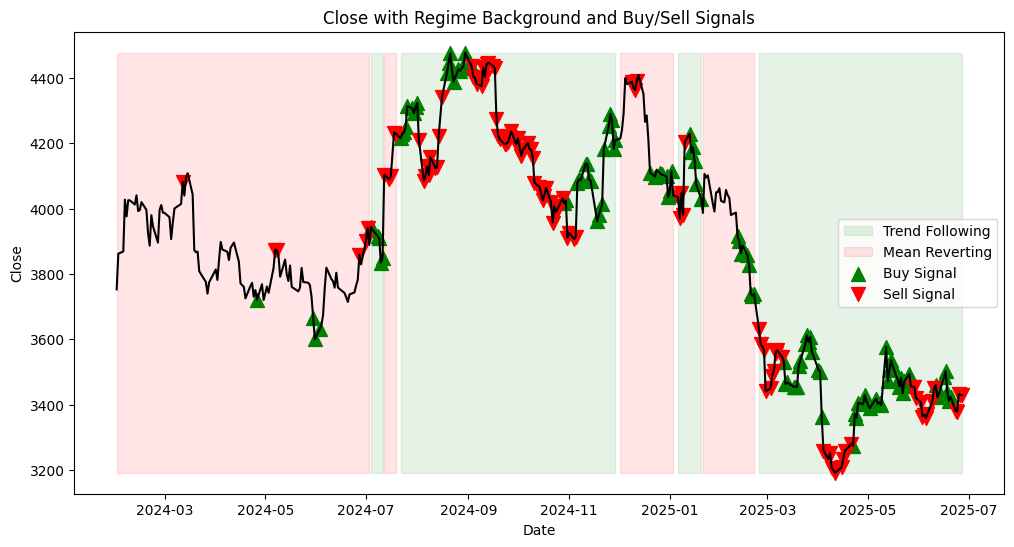

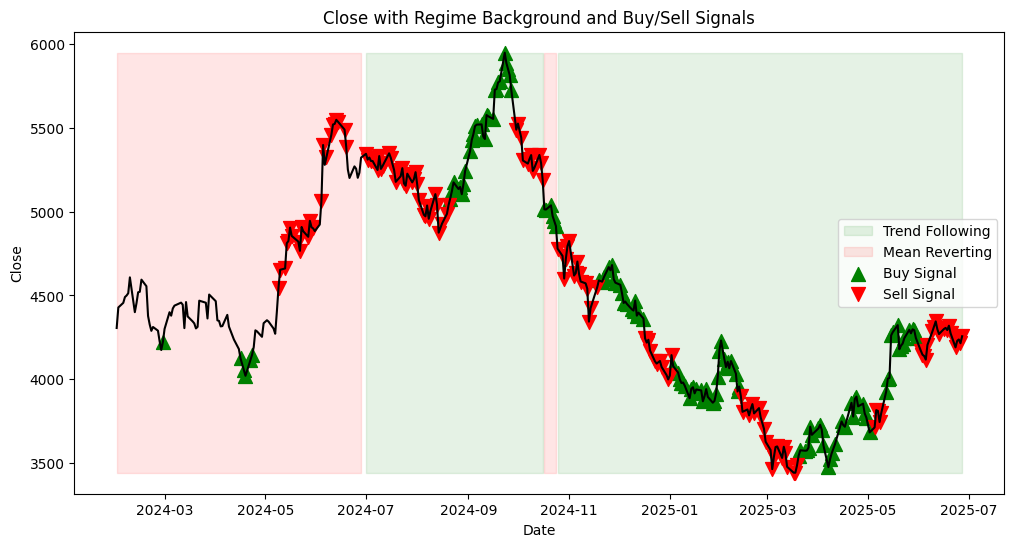

In [ ]:
plotter(stock_1_df)
plotter(stock_2_df)

In [ ]:
def benchmark_metrics(df, trade_wise_df, daily_df, capital):
    # Ensure index is integer-position based for .iloc
    df = df.reset_index(drop=True)
    trade_wise_df = trade_wise_df.reset_index(drop=True)
    daily_df = daily_df.reset_index(drop=True)

    # Benchmark return
    benchmark_return = ((df.iloc[-1]["Close"] - df.iloc[0]["Close"]) * 100) / df.iloc[0]["Close"]

    # Gross profit
    gross_profit = daily_df.iloc[-1]["Profit from initial Capital"]

    # Trade counts
    total_trades = len(trade_wise_df)
    winning_trades = (trade_wise_df["Return for trade in %"] > 0).sum()
    losing_trades = total_trades - winning_trades

    # Holding times
    max_holding_time = trade_wise_df["Trade Duration"].max()
    avg_holding_time = trade_wise_df["Trade Duration"].mean()

    # Max drawdown per trade
    drawdowns = []
    for i in range(len(trade_wise_df)):
        entry_idx = int(trade_wise_df.iloc[i]["Entry Index"])
        exit_idx = int(trade_wise_df.iloc[i]["Exit Index"])
        initial_value = daily_df.iloc[entry_idx]["Portfolio Value"]

        max_drawdown = 0
        peak_value = initial_value
        for j in range(entry_idx + 1, exit_idx + 1):
            peak_value = max(peak_value, daily_df.iloc[j]["Portfolio Value"])
            drawdown_value = (peak_value - daily_df.iloc[j]["Portfolio Value"]) / peak_value
            max_drawdown = max(max_drawdown, drawdown_value)
        drawdowns.append(max_drawdown)

    # Sharpe ratio (trade-wise)
    mean_return = trade_wise_df["Return for trade in %"].mean()
    std_return = trade_wise_df["Return for trade in %"].std()
    rfr = 0
    sharpe = (mean_return - rfr) * np.sqrt(252) / std_return if std_return != 0 else np.nan

    # Sharpe ratio (daily)
    mean_return_daily = daily_df["Daily Returns in %"].mean()
    std_return_daily = daily_df["Daily Returns in %"].std()
    sharpe_daily = ((mean_return_daily - rfr) * np.sqrt(252) / std_return_daily
                    if std_return_daily != 0 else np.nan)

    # Print results
    print(f"Benchmark Return: {benchmark_return:.2f} %")
    print(f"Gross Profit: {gross_profit:.2f} %")
    print(f"Max Holding Time: {max_holding_time}")
    print(f"Average Holding Time: {avg_holding_time}")
    print(f"Total Trades: {total_trades}")
    print(f"Winning Trades: {winning_trades}")
    print(f"Losing Trades: {losing_trades}")
    print(f"Max Drawdown: {max(drawdowns) * 100:.2f} %")
    print(f"Sharpe Ratio (trade-wise): {sharpe:.4f}")
    print(f"Sharpe Ratio (daily): {sharpe_daily:.4f}")

    final_value = (1 + (gross_profit / 100)) * capital / 2
    return final_value

In [ ]:
final_value_stock_1=benchmark_metrics(stock_1_df,trade_wise_stock_1,daily_stock_1,capital=capital)

Benchmark Return: -8.62 %
Gross Profit: 6.65 %
Max Holding Time: 38
Average Holding Time: 9.357142857142858
Total Trades: 28
Winning Trades: 11
Losing Trades: 17
Max Drawdown: 6.55 %
Sharpe Ratio (trade-wise): 1.0676
Sharpe Ratio (daily): 0.3493


In [ ]:
final_value_stock_2=benchmark_metrics(stock_2_df,trade_wise_stock_2,daily_stock_2,capital=capital)

Benchmark Return: -1.15 %
Gross Profit: 22.06 %
Max Holding Time: 47
Average Holding Time: 12.375
Total Trades: 24
Winning Trades: 12
Losing Trades: 12
Max Drawdown: 7.40 %
Sharpe Ratio (trade-wise): 3.0357
Sharpe Ratio (daily): 0.7669


In [ ]:
plot_portfolio(stock_1_df,daily_stock_1)

In [ ]:
plot_portfolio(stock_2_df,daily_stock_2)

In [ ]:
def plot_combined_portfolio(daily_df1, daily_df2, total_capital=100000, title="Combined Portfolio Value"):
    import pandas as pd
    import plotly.express as px

    # Align both portfolios on dates
    combined = pd.concat(
        [daily_df1["Portfolio Value"], daily_df2["Portfolio Value"]],
        axis=1
    )
    combined.columns = ["Stock 1", "Stock 2"]
    combined = combined.dropna()

    # Scale each to half the capital
    half_capital = total_capital / 2
    combined["Stock 1 Allocated"] = (combined["Stock 1"] / combined["Stock 1"].iloc[0]) * half_capital
    combined["Stock 2 Allocated"] = (combined["Stock 2"] / combined["Stock 2"].iloc[0]) * half_capital

    # Total portfolio value
    combined["Total Portfolio"] = combined["Stock 1 Allocated"] + combined["Stock 2 Allocated"]

    # Plot
    fig = px.line(
        combined,
        x=combined.index,
        y="Total Portfolio",
        title=title
    )
    fig.show()


In [ ]:
plot_combined_portfolio(daily_stock_1,daily_stock_2)

In [ ]:
nifty_50=yf.download(tickers,start="2024-06-01",end="2025-06-01",interval="1d")
nifty_50 = nifty_50['Close']

[*********************100%***********************]  48 of 48 completed


In [ ]:
nifty_50=yf.download(tickers,start="2024-06-01",end="2025-06-01",interval="1d")
nifty_50 = nifty_50["Close"]

[*********************100%***********************]  48 of 48 completed


In [ ]:
capital=100000
capital_per_stock=capital/48 #out of 50 -2 stocks data could not be retrieved from yfinance
capital_retained=0
for stock in nifty_50:
    shares=capital_per_stock/nifty_50.loc[nifty_50.index[0],stock]
    capital_retained+=shares*nifty_50.loc[nifty_50.index[-1],stock]

R_market=((capital_retained-capital)/capital)*100
print(f"R-Market= {R_market} %")

R-Market= 5.916330600375615 %


In [ ]:
R_user=((final_value_stock_1+final_value_stock_2)-capital)*100/capital
print(f"R-User= {R_user} %")

R-User= 14.355534423828125 %


In [ ]:
user_score=R_user*100/R_market
print(f"User Score= {user_score} %")

User Score= 242.64253290572915 %


In [ ]:
correlations1=log_returns.corrwith(log_returns[stock_1])
correlations2=log_returns.corrwith(log_returns[stock_2])
correlations1.sort_values(inplace=True,ascending=False)
correlations2.sort_values(inplace=True,ascending=False)

hedge_stock1=correlations1.index[1]
hedge_stock2=correlations2.index[1]
print(hedge_stock1)
print(hedge_stock2)

INFY.NS
BAJAJ-AUTO.NS


In [ ]:
correlations1

Ticker
TCS.NS           1.000000
INFY.NS          0.741439
HCLTECH.NS       0.698823
WIPRO.NS         0.681670
TECHM.NS         0.652637
LT.NS            0.388783
BAJFINANCE.NS    0.326697
HINDALCO.NS      0.320281
ASIANPAINT.NS    0.320126
HDFCBANK.NS      0.315605
BAJAJFINSV.NS    0.315591
GRASIM.NS        0.307255
ULTRACEMCO.NS    0.300528
SBIN.NS          0.289029
RELIANCE.NS      0.277858
INDUSINDBK.NS    0.271779
ICICIBANK.NS     0.270566
SBILIFE.NS       0.269542
TITAN.NS         0.256341
TATASTEEL.NS     0.254979
M&M.NS           0.252569
JSWSTEEL.NS      0.251899
SUNPHARMA.NS     0.241054
BPCL.NS          0.234498
IOC.NS           0.234188
DIVISLAB.NS      0.232455
AXISBANK.NS      0.231600
HINDUNILVR.NS    0.231466
HDFCLIFE.NS      0.230598
HEROMOTOCO.NS    0.229126
KOTAKBANK.NS     0.226448
MARUTI.NS        0.225915
NESTLEIND.NS     0.214444
ADANIPORTS.NS    0.214035
APOLLOHOSP.NS    0.208437
BHARTIARTL.NS    0.206367
SHREECEM.NS      0.195816
DRREDDY.NS       0.182704
EICHE

In [ ]:
stock1 = stock_1
stock2 = stock_2

tickers = [stock1,stock2,hedge_stock1,hedge_stock2]
df = yf.download(tickers,start='2022-03-01',end='2024-05-31')['Close']

#changes

for ticker in tickers:
  stock1_df=yf.download(stock1,start='2022-03-01',end='2024-05-31')
  stock2_df=yf.download(stock2,start='2022-03-01',end='2024-05-31')

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2022-03-02,2167.412598,2231.908777,2162.678067,2231.462128,855090
2022-03-03,2159.462402,2204.663450,2148.385574,2180.544360,831912
2022-03-04,2064.683350,2147.134944,2055.571738,2143.918978,1266961
2022-03-07,1964.097778,2045.477459,1938.549541,2045.477459,1284637
2022-03-08,2011.397827,2018.186991,1917.780210,1948.286302,1081826
...,...,...,...,...,...
2024-05-24,4882.800293,4958.976386,4846.310224,4870.207921,458258
2024-05-27,4849.982910,4892.816908,4817.642787,4890.145926,380940
2024-05-28,4945.429688,4984.590736,4812.872777,4850.984810,727224


In [ ]:
stock1_df=stock1_df.droplevel(1,axis=1)
stock2_df=stock2_df.droplevel(1,axis=1)

In [ ]:
def sharpe_ratio(return_series, N, rf):
    mean = return_series.mean() * N -rf
    sigma = return_series.std() * np.sqrt(N)
    return mean / sigma

In [ ]:
stock1_signals=strategy(stock1_df)['signal']
stock2_signals=strategy(stock2_df)['signal']

In [ ]:
def hedged_backtest(stock,hedge_stock,df,stock_signals):
  close= list(df[stock])
  close_hedge = list(df[hedge_stock])
  opening_capital = 500000
  capital = opening_capital
  portfolio_value = [opening_capital]
  entry_price = 0
  entry_price_hedge = 0
  vol = 0
  hedge_vol = 0
  no_of_buy_signals = 0
  no_of_sell_signals = 0
  for i in stock_signals:
    if i == 1:
      no_of_buy_signals+=1
    if i == -1:
      no_of_sell_signals+=1

  long_trade = 0
  short_trade = 0
  for i in range(1,len(stock_signals)):
    if stock_signals[i] == 0:
      if long_trade:
        portfolio_value.append(capital+ vol*(close[i] - entry_price) + hedge_vol*(entry_price_hedge - close_hedge[i]))
      elif short_trade:
        portfolio_value.append(capital- vol*(close[i] - entry_price) - hedge_vol*(entry_price_hedge - close_hedge[i]))
      else:
        portfolio_value.append(capital)
    if stock_signals[i] == -1:
      if long_trade:
        long_trade = 0
        capital+=(vol*(close[i] - entry_price) + hedge_vol*(entry_price_hedge - close_hedge[i]))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_buy_signals > 0:
        entry_price = close[i]
        entry_price_hedge = close_hedge[i]
        vol = int(capital/close[i])
        hedge_vol = int(capital/close_hedge[i])
        short_trade = 1
      no_of_sell_signals-=1
      portfolio_value.append(capital)
    if stock_signals[i] == 1:
      if short_trade:
        short_trade = 0
        capital-=(vol*(close[i] - entry_price) + hedge_vol*(entry_price_hedge - close_hedge[i]))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_sell_signals > 0:
        entry_price = close[i]
        entry_price_hedge = close_hedge[i]
        vol = int(capital/close[i])
        hedge_vol = int(capital/close_hedge[i])
        long_trade = 1
      no_of_buy_signals-=1
      portfolio_value.append(capital)
  return portfolio_value

In [ ]:
def backtest(stock,df,stock_signals):
  close= list(df[stock])
  opening_capital = 500000
  capital = opening_capital
  portfolio_value = [opening_capital]
  entry_price = 0
  entry_price_hedge = 0
  vol = 0
  no_of_buy_signals = 0
  no_of_sell_signals = 0
  for i in stock_signals:
    if i == 1:
      no_of_buy_signals+=1
    if i == -1:
      no_of_sell_signals+=1

  long_trade = 0
  short_trade = 0
  for i in range(1,len(stock_signals)):
    if stock_signals[i] == 0:
      if long_trade:
        portfolio_value.append(capital+ vol*(close[i] - entry_price))
      elif short_trade:
        portfolio_value.append(capital- vol*(close[i] - entry_price) )
      else:
        portfolio_value.append(capital)
    if stock_signals[i] == -1:
      if long_trade:
        long_trade = 0
        capital+=(vol*(close[i] - entry_price))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_buy_signals > 0:
        entry_price = close[i]
        vol = int(capital/close[i])
        short_trade = 1
      no_of_sell_signals-=1
      portfolio_value.append(capital)
    if stock_signals[i] == 1:
      if short_trade:
        short_trade = 0
        capital-=(vol*(close[i] - entry_price))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_sell_signals > 0:
        entry_price = close[i]
        vol = int(capital/close[i])
        long_trade = 1
      no_of_buy_signals-=1
      portfolio_value.append(capital)
  return portfolio_value

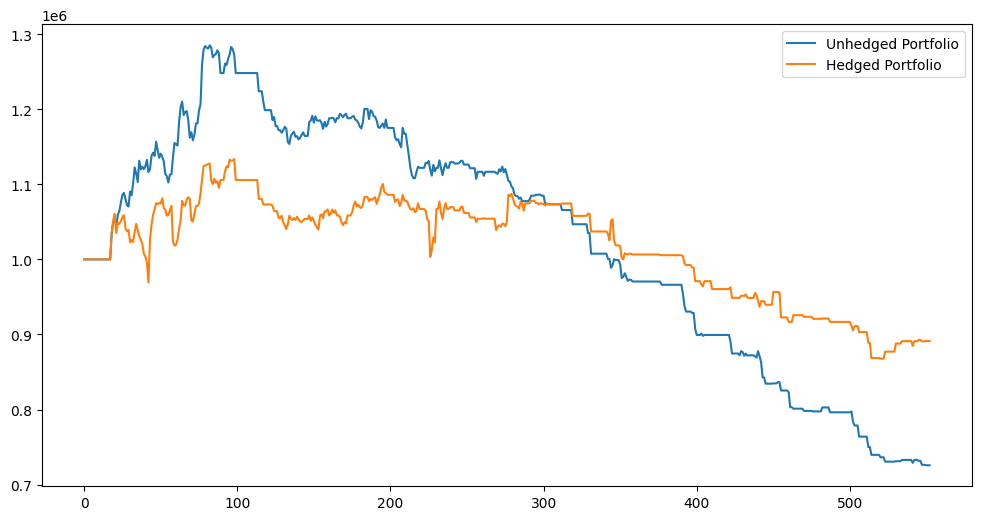

******BACKTEST METRICS******
Hedged Portfolio Returns: -10.864671105957031%
Unhedged Portfolio Returns: -27.426663793945313%
Hedged Portfolio Sharpe Ratio: -0.374956007144664
Unhedged Portfolio Sharpe Ratio: -1.330405739100152


In [ ]:
stock1_portfolio = backtest(stock1,df,stock1_signals)
hedged_stock1_portfolio = hedged_backtest(stock1,hedge_stock1,df,stock1_signals)
stock2_portfolio = backtest(stock2,df,stock2_signals)
hedged_stock2_portfolio = hedged_backtest(stock2,hedge_stock2,df,stock2_signals)
final_portfolio = []
final_hedged_portfolio = []
for i in range(len(stock1_portfolio)):
  final_portfolio.append(stock1_portfolio[i] + stock2_portfolio[i])
  final_hedged_portfolio.append(hedged_stock1_portfolio[i] + hedged_stock2_portfolio[i])

plt.figure(figsize=(12,6))
plt.plot(final_portfolio,label='Unhedged Portfolio')
plt.plot(final_hedged_portfolio,label='Hedged Portfolio')
plt.legend()
plt.show()

print('******BACKTEST METRICS******')
print(f'Hedged Portfolio Returns: {(final_hedged_portfolio[-1] - final_hedged_portfolio[0])*100/final_hedged_portfolio[0]}%')
print(f'Unhedged Portfolio Returns: {(final_portfolio[-1] - final_portfolio[0])*100/final_portfolio[0]}%')
print(f'Hedged Portfolio Sharpe Ratio: {sharpe_ratio(pd.Series(final_hedged_portfolio).pct_change().dropna(),255,0)}')
print(f'Unhedged Portfolio Sharpe Ratio: {sharpe_ratio(pd.Series(final_portfolio).pct_change().dropna(),255,0)}')